In [1]:
#Cargo los paquetes de librerias a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [2]:
#Ruta a la base
base= pd.read_csv(r"C:\Users\juanc\Desktop\Documentos Juan\Maestria\Programacion\spotify_churn_dataset.csv")

In [3]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


In [ ]:
base['gender'].value_counts(normalize=True)

gender
Male      0.336375
Female    0.332375
Other     0.331250
Name: proportion, dtype: float64

In [14]:
base['is_churned'].value_counts(normalize=True)

is_churned
0    0.741125
1    0.258875
Name: proportion, dtype: float64

In [4]:

pd.crosstab(base['is_churned'], base['device_type'])

device_type,Desktop,Mobile,Web
is_churned,,,
0,2063,1900,1966
1,715,699,657


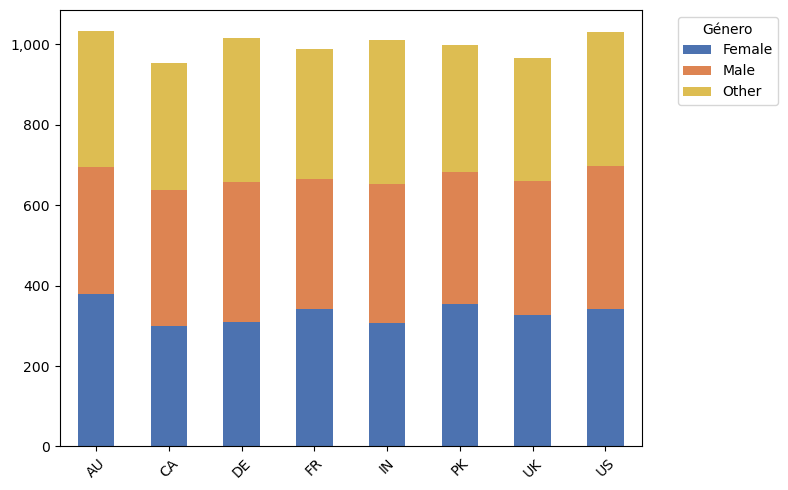

In [24]:
# 1. Contar cantidad de registros por combinación de paises y genero
tabla_paises_generos = base.groupby(['country', 'gender']).size().unstack()

# 2. Colores para los géneros
colores = ['#4c72b0', '#dd8452', "#ddbd52"]

# 3. Crear figura
fig, ax = plt.subplots(figsize=(8, 5))  # Aumentamos tamaño

tabla_paises_generos.plot(kind='bar', stacked=True, color=colores, ax=ax)

# 4. Formato del eje y
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# 5. Personalizar ejes
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# 6. Leyenda fuera del gráfico (a la derecha)
ax.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')

# 7. Ajuste de layout
plt.tight_layout()
plt.show()


In [10]:
base['skip_rate'].describe()

count    8000.000000
mean        0.300127
std         0.173594
min         0.000000
25%         0.150000
50%         0.300000
75%         0.450000
max         0.600000
Name: skip_rate, dtype: float64

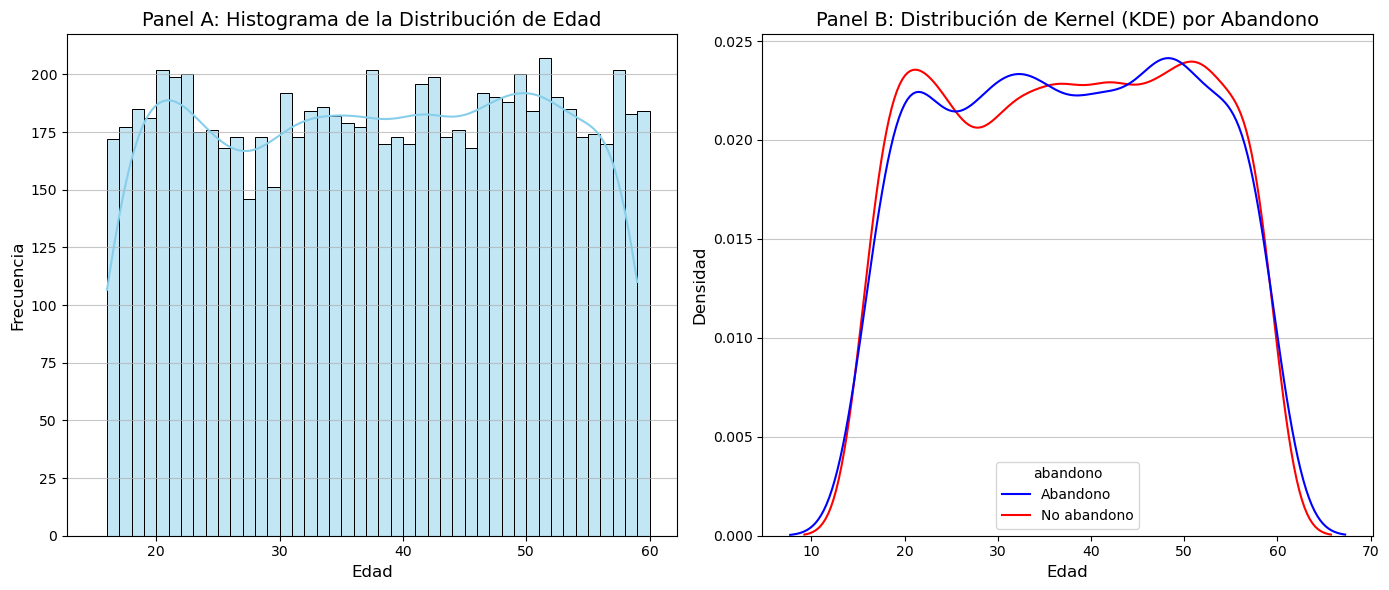

In [ ]:
# Configuración del lienzo para dos paneles (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel A: Histograma de Edad (Distribución General) ---
sns.histplot(
    data=base,
    x='age',
    bins=range(15, base['age'].max() + 2, 1), # Agrupación por tramos de 5 años
    kde=True,
    ax=axes[0],
    color='skyblue'
)
axes[0].set_title('Panel A: Histograma de la Distribución de Edad', fontsize=14)
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].grid(axis='y', alpha=0.7)

# --- Panel B: Distribución de Kernel (KDE) por Condición de abandono ---
# Mapear la variable 'is_churned' para una mejor leyenda
base['abandono'] = base['is_churned'].map({0: 'No abandono', 1: 'Abandono'})

sns.kdeplot(
    data=base,
    x='age',
    hue='abandono', #Separar por abandono
    fill=False,
    common_norm=False,
    ax=axes[1],
    palette={'No abandono': 'red', 'Abandono': 'blue'}
)
axes[1].set_title('Panel B: Distribución de Kernel (KDE) por Abandono', fontsize=14)
axes[1].set_xlabel('Edad', fontsize=12)
axes[1].set_ylabel('Densidad', fontsize=12)
axes[1].grid(axis='y', alpha=0.7)

# Ajustar diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

# Eliminar la columna temporal
del base['abandono']

In [6]:
base['listening_time'].describe()

count    8000.000000
mean      154.068250
std        84.015596
min        10.000000
25%        81.000000
50%       154.000000
75%       227.000000
max       299.000000
Name: listening_time, dtype: float64

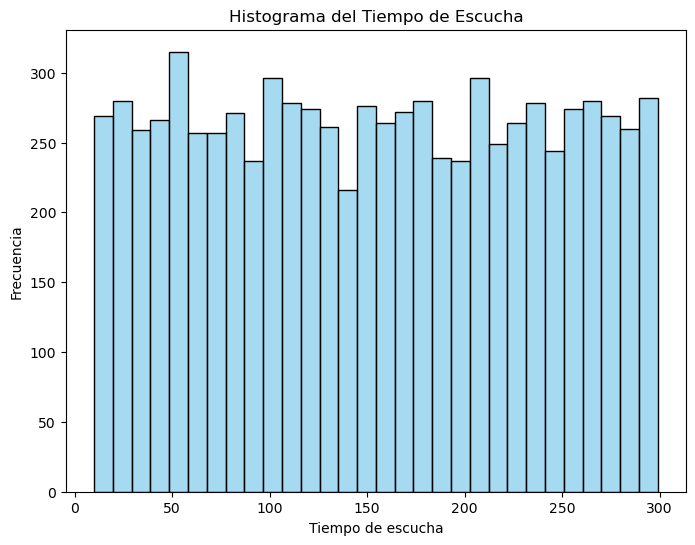

In [ ]:
#Grafico de dispersion para el tiempo de escucha
plt.figure(figsize=(8, 6))
sns.histplot(data=base, x='listening_time', bins=30, kde=False, color='skyblue')

plt.title('Histograma del Tiempo de Escucha')
plt.xlabel('Tiempo de escucha')
plt.ylabel('Frecuencia')
plt.grid(False)
plt.show()

In [13]:
#Genero dummies para las variables categoricas
variables_categoricas = ['gender', 'country', 'subscription_type', 'device_type', 'is_churned']

# Generar dummies
dummies = pd.get_dummies(base, columns=variables_categoricas, prefix_sep='_', drop_first=False)

In [14]:
dummies

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,gender_Female,gender_Male,gender_Other,...,country_US,subscription_type_Family,subscription_type_Free,subscription_type_Premium,subscription_type_Student,device_type_Desktop,device_type_Mobile,device_type_Web,is_churned_0,is_churned_1
0,1,54,26,23,0.20,31,0,True,False,False,...,False,False,True,False,False,True,False,False,False,True
1,2,33,141,62,0.34,0,1,False,False,True,...,False,True,False,False,False,False,False,True,True,False
2,3,38,199,38,0.04,0,1,False,True,False,...,False,False,False,True,False,False,True,False,False,True
3,4,22,36,2,0.31,0,1,True,False,False,...,False,False,False,False,True,False,True,False,True,False
4,5,29,250,57,0.36,0,1,False,False,True,...,True,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,44,237,36,0.30,0,1,False,False,True,...,False,False,False,False,True,False,True,False,False,True
7996,7997,34,61,64,0.59,0,1,False,True,False,...,False,False,False,True,False,False,True,False,True,False
7997,7998,17,81,62,0.33,5,0,True,False,False,...,True,False,True,False,False,True,False,False,True,False
7998,7999,34,245,94,0.27,0,1,True,False,False,...,False,False,False,False,True,True,False,False,True,False


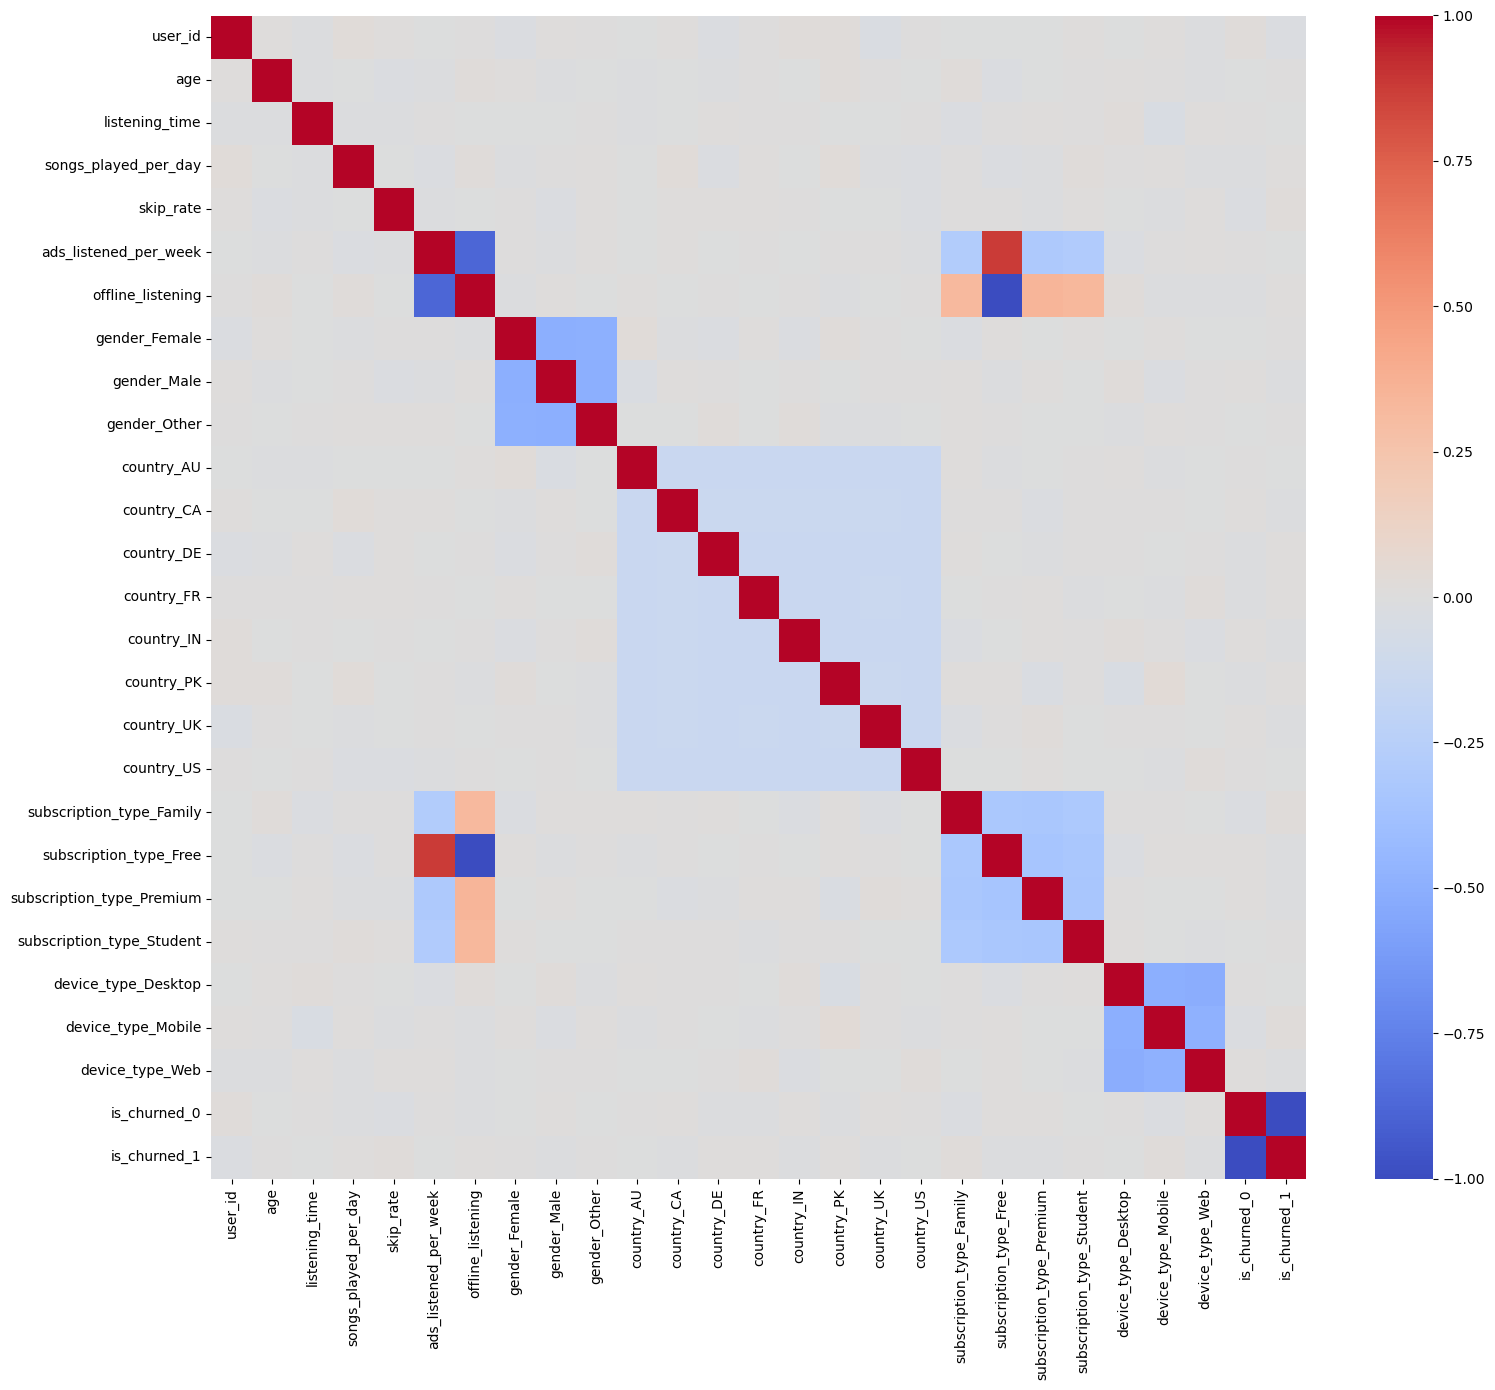

In [16]:
corr_matrix = dummies.corr()

#grafico la matriz de correlacion con heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)

#plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

